# 🧠 Multi-Label Multi-View ViT — Knee MRI Classification

**EEEM068 Applied Machine Learning | University of Surrey | Spring 2026**

This notebook trains a Vision Transformer (ViT-Small) to perform **multi-label classification** of knee MRI scans, simultaneously predicting the presence of:
- ACL tear
- Meniscal tear
- General abnormality

All three MRI planes (sagittal, coronal, axial) are used and fused through a learned gating mechanism.

---

In [1]:
!pip install -q timm

## 📦 1. Imports

Core libraries for data handling, model building, and evaluation.

In [2]:
import os
import gc
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T

import timm

warnings.filterwarnings("ignore")

## ⚙️ 2. Configuration

All hyperparameters and paths are centralised in `CFG`. Modify this class to tune the experiment.

In [3]:
class CFG:
    ROOT = Path("/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v1.0")

    IMAGE_SIZE = 224
    BATCH_SIZE = 4
    EPOCHS = 15
    NUM_WORKERS = 2

    MODEL_NAME = "vit_small_patch16_224"
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    BACKBONE_LR = 5e-6
    HEAD_LR = 5e-5
    WEIGHT_DECAY = 1e-4

    SEED = 42

    NUM_SLICES_PER_VIEW = 5
    NUM_LABELS = 3
    LABEL_NAMES = ["acl", "meniscus", "abnormal"]

print("Device:", CFG.DEVICE)

Device: cuda


## 🌱 3. Reproducibility

Fix all random seeds for reproducible training.

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)

## 📂 4. Dataset Exploration

Verify that the MRNet dataset is mounted correctly and list the directory structure.

In [5]:
print("Root exists:", CFG.ROOT.exists())
for p in sorted(CFG.ROOT.glob("*")):
    print(p)

Root exists: True
/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v1.0/train
/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v1.0/train-abnormal.csv
/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v1.0/train-acl.csv
/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v1.0/train-meniscus.csv
/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v1.0/valid
/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v1.0/valid-abnormal.csv
/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v1.0/valid-acl.csv
/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v1.0/valid-meniscus.csv


## 🏷️ 5. Load Labels

Read the three binary CSV label files (ACL, abnormal, meniscus) and merge them into a single DataFrame per split.

In [6]:
def load_split_labels(root, split):
    acl = pd.read_csv(root / f"{split}-acl.csv", header=None, names=["id", "acl"])
    abnormal = pd.read_csv(root / f"{split}-abnormal.csv", header=None, names=["id", "abnormal"])
    meniscus = pd.read_csv(root / f"{split}-meniscus.csv", header=None, names=["id", "meniscus"])

    df = acl.merge(abnormal, on="id").merge(meniscus, on="id")
    df["id"] = df["id"].astype(str).str.zfill(4)
    df["split"] = split
    return df

train_df = load_split_labels(CFG.ROOT, "train")
valid_df = load_split_labels(CFG.ROOT, "valid")

print(train_df.head())
print(valid_df.head())
print(train_df.shape, valid_df.shape)

     id  acl  abnormal  meniscus  split
0  0000    0         1         0  train
1  0001    1         1         1  train
2  0002    0         1         0  train
3  0003    0         1         1  train
4  0004    0         1         0  train
     id  acl  abnormal  meniscus  split
0  1130    0         0         0  valid
1  1131    0         0         0  valid
2  1132    0         0         0  valid
3  1133    0         0         0  valid
4  1134    0         0         0  valid
(1130, 5) (120, 5)


## 🗂️ 6. Attach File Paths

Add the `.npy` file paths for each MRI plane to the DataFrames.

In [7]:
def add_paths(df, root, split):
    df = df.copy()
    df["sagittal_path"] = df["id"].apply(lambda x: str(root / split / "sagittal" / f"{x}.npy"))
    df["coronal_path"]  = df["id"].apply(lambda x: str(root / split / "coronal" / f"{x}.npy"))
    df["axial_path"]    = df["id"].apply(lambda x: str(root / split / "axial" / f"{x}.npy"))
    return df

train_df = add_paths(train_df, CFG.ROOT, "train")
valid_df = add_paths(valid_df, CFG.ROOT, "valid")

train_df.head()

,id,acl,abnormal,meniscus,split,sagittal_path,coronal_path,axial_path
0,0000,0,1,0,train,/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...,/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...,/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...
1,0001,1,1,1,train,/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...,/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...,/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...
2,0002,0,1,0,train,/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...,/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...,/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...
3,0003,0,1,1,train,/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...,/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...,/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...
4,0004,0,1,0,train,/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...,/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...,/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...


## ✅ 7. Sanity Check Paths

Verify that the `.npy` files exist for the first few samples.

In [8]:
for i in range(3):
    row = train_df.iloc[i]
    print(row["id"])
    print(" sagittal:", os.path.exists(row["sagittal_path"]))
    print(" coronal :", os.path.exists(row["coronal_path"]))
    print(" axial   :", os.path.exists(row["axial_path"]))
    print()

0000
 sagittal: True
 coronal : True
 axial   : True

0001
 sagittal: True
 coronal : True
 axial   : True

0002
 sagittal: True
 coronal : True
 axial   : True



## 🎯 8. Multi-Label Target Construction

Build a multi-hot target vector `[acl, meniscus, abnormal]` per sample.

In [9]:
train_df["target"] = train_df.apply(lambda r: [r["acl"], r["meniscus"], r["abnormal"]], axis=1)
valid_df["target"] = valid_df.apply(lambda r: [r["acl"], r["meniscus"], r["abnormal"]], axis=1)

print(train_df[["id", "acl", "meniscus", "abnormal", "target"]].head())

     id  acl  meniscus  abnormal     target
0  0000    0         0         1  [0, 0, 1]
1  0001    1         1         1  [1, 1, 1]
2  0002    0         0         1  [0, 0, 1]
3  0003    0         1         1  [0, 1, 1]
4  0004    0         0         1  [0, 0, 1]


## 📊 9. Class Distribution

Examine the label imbalance across the training set.

In [10]:
for label in CFG.LABEL_NAMES:
    pos = train_df[label].sum()
    neg = len(train_df) - pos
    print(f"{label}: positive={pos}, negative={neg}")

acl: positive=208, negative=922
meniscus: positive=397, negative=733
abnormal: positive=913, negative=217


## ⚖️ 10. Positive Class Weights

Compute per-label positive weights (`neg / pos`) to penalise the loss on underrepresented positive cases.

In [11]:
pos_weights = []

for label in CFG.LABEL_NAMES:
    pos = train_df[label].sum()
    neg = len(train_df) - pos
    pw = neg / max(pos, 1)
    pos_weights.append(pw)

pos_weights = torch.tensor(pos_weights, dtype=torch.float32)
print("pos_weights:", pos_weights)

pos_weights: tensor([4.4327, 1.8463, 0.2377])


## 🔁 11. Weighted Sampler

Create a `WeightedRandomSampler` to oversample rare combinations and reduce batch-level imbalance.

In [12]:
label_freq = {}
for label in CFG.LABEL_NAMES:
    label_freq[label] = train_df[label].mean()

def compute_sample_weight(row):
    weight = 1.0
    for label in CFG.LABEL_NAMES:
        if row[label] == 1:
            weight += 1.0 / max(label_freq[label], 1e-6)
    return weight

train_sample_weights = train_df.apply(compute_sample_weight, axis=1).values
train_sample_weights = torch.DoubleTensor(train_sample_weights)

sampler = WeightedRandomSampler(
    weights=train_sample_weights,
    num_samples=len(train_sample_weights),
    replacement=True
)

print(train_sample_weights[:10])

tensor([ 2.2377, 10.5167,  2.2377,  5.0840,  2.2377,  5.0840,  2.2377,  2.2377,
         2.2377,  2.2377], dtype=torch.float64)


## 🖼️ 12. Slice Loading Utilities

- `normalize_to_uint8`: min-max normalise a volume slice to 8-bit
- `select_informative_slices`: pick top-k slices by pixel variance from the central 60% of the volume
- `load_npy_slices_as_pil_list`: load and return PIL images for the selected slices

In [13]:
def normalize_to_uint8(img):
    img = img.astype(np.float32)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    img = (img * 255.0).clip(0, 255).astype(np.uint8)
    return img

def select_informative_slices(volume, num_slices=5):
    """
    volume shape: [D, H, W]
    pick top-k slices by variance from the middle 60% region
    """
    D = volume.shape[0]
    start = int(D * 0.2)
    end = int(D * 0.8)
    if end <= start:
        start, end = 0, D

    candidate_idxs = list(range(start, end))
    slice_vars = [volume[i].var() for i in candidate_idxs]

    ranked = sorted(zip(candidate_idxs, slice_vars), key=lambda x: x[1], reverse=True)
    selected = [idx for idx, _ in ranked[:num_slices]]
    selected = sorted(selected)

    if len(selected) < num_slices:
        while len(selected) < num_slices:
            selected.append(selected[-1])

    return selected[:num_slices]

def load_npy_slices_as_pil_list(path, num_slices=5):
    volume = np.load(path)  # [D,H,W]
    if volume.ndim != 3:
        raise ValueError(f"Expected 3D volume, got {volume.shape}")

    idxs = select_informative_slices(volume, num_slices=num_slices)
    images = []

    for idx in idxs:
        img = normalize_to_uint8(volume[idx])
        img = Image.fromarray(img).convert("RGB")
        images.append(img)

    return images, idxs

## 🔄 13. Data Augmentation

**Training** transforms include random affine (rotation ±20°, translation ±8%, scale 0.95–1.05) and horizontal flip.
**Validation** uses only resize + normalise — no augmentation.

In [14]:
train_tfms = T.Compose([
    T.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    T.RandomAffine(
        degrees=20,
        translate=(0.08, 0.08),
        scale=(0.95, 1.05)
    ),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.25, 0.25, 0.25])
])

valid_tfms = T.Compose([
    T.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.25, 0.25, 0.25])
])

## 🗃️ 14. Dataset Class

`MultiLabelMultiViewMRNetDataset` loads all three views per exam, applies transforms to each slice, and returns a dictionary of stacked tensors with shape `[S, C, H, W]`.

In [15]:
class MultiLabelMultiViewMRNetDataset(Dataset):
    def __init__(self, df, transforms=None, num_slices_per_view=5):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.num_slices_per_view = num_slices_per_view

    def __len__(self):
        return len(self.df)

    def process_view(self, path):
        pil_list, idxs = load_npy_slices_as_pil_list(path, num_slices=self.num_slices_per_view)
        tensor_list = [self.transforms(img) for img in pil_list]
        return torch.stack(tensor_list, dim=0), idxs

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        sag, sag_idxs = self.process_view(row["sagittal_path"])
        cor, cor_idxs = self.process_view(row["coronal_path"])
        axi, axi_idxs = self.process_view(row["axial_path"])

        target = torch.tensor(row["target"], dtype=torch.float32)

        return {
            "sag": sag,
            "cor": cor,
            "axi": axi,
            "target": target,
            "id": row["id"],
            "sag_idxs": sag_idxs,
            "cor_idxs": cor_idxs,
            "axi_idxs": axi_idxs
        }

## 🔌 15. DataLoaders

Instantiate train and validation `DataLoader`s. The training loader uses the weighted sampler.

In [16]:
train_ds = MultiLabelMultiViewMRNetDataset(
    train_df,
    transforms=train_tfms,
    num_slices_per_view=CFG.NUM_SLICES_PER_VIEW
)

valid_ds = MultiLabelMultiViewMRNetDataset(
    valid_df,
    transforms=valid_tfms,
    num_slices_per_view=CFG.NUM_SLICES_PER_VIEW
)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG.BATCH_SIZE,
    sampler=sampler,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

print("Train size:", len(train_ds))
print("Valid size:", len(valid_ds))

Train size: 1130
Valid size: 120


## 🔍 16. Dataset Sanity Check

Inspect the shape and slice indices of a single sample.

In [17]:
sample = train_ds[0]

print("Exam ID:", sample["id"])
print("Sag shape:", sample["sag"].shape)
print("Cor shape:", sample["cor"].shape)
print("Axi shape:", sample["axi"].shape)
print("Target:", sample["target"])
print("Sag slice idxs:", sample["sag_idxs"])
print("Cor slice idxs:", sample["cor_idxs"])
print("Axi slice idxs:", sample["axi_idxs"])

Exam ID: 0000
Sag shape: torch.Size([5, 3, 224, 224])
Cor shape: torch.Size([5, 3, 224, 224])
Axi shape: torch.Size([5, 3, 224, 224])
Target: tensor([0., 0., 1.])
Sag slice idxs: [7, 8, 9, 10, 11]
Cor slice idxs: [17, 18, 19, 20, 21]
Axi slice idxs: [26, 27, 28, 29, 30]


## 👁️ 17. Visualise a Sample

Denormalise and display the selected slices across all three views for a training example.

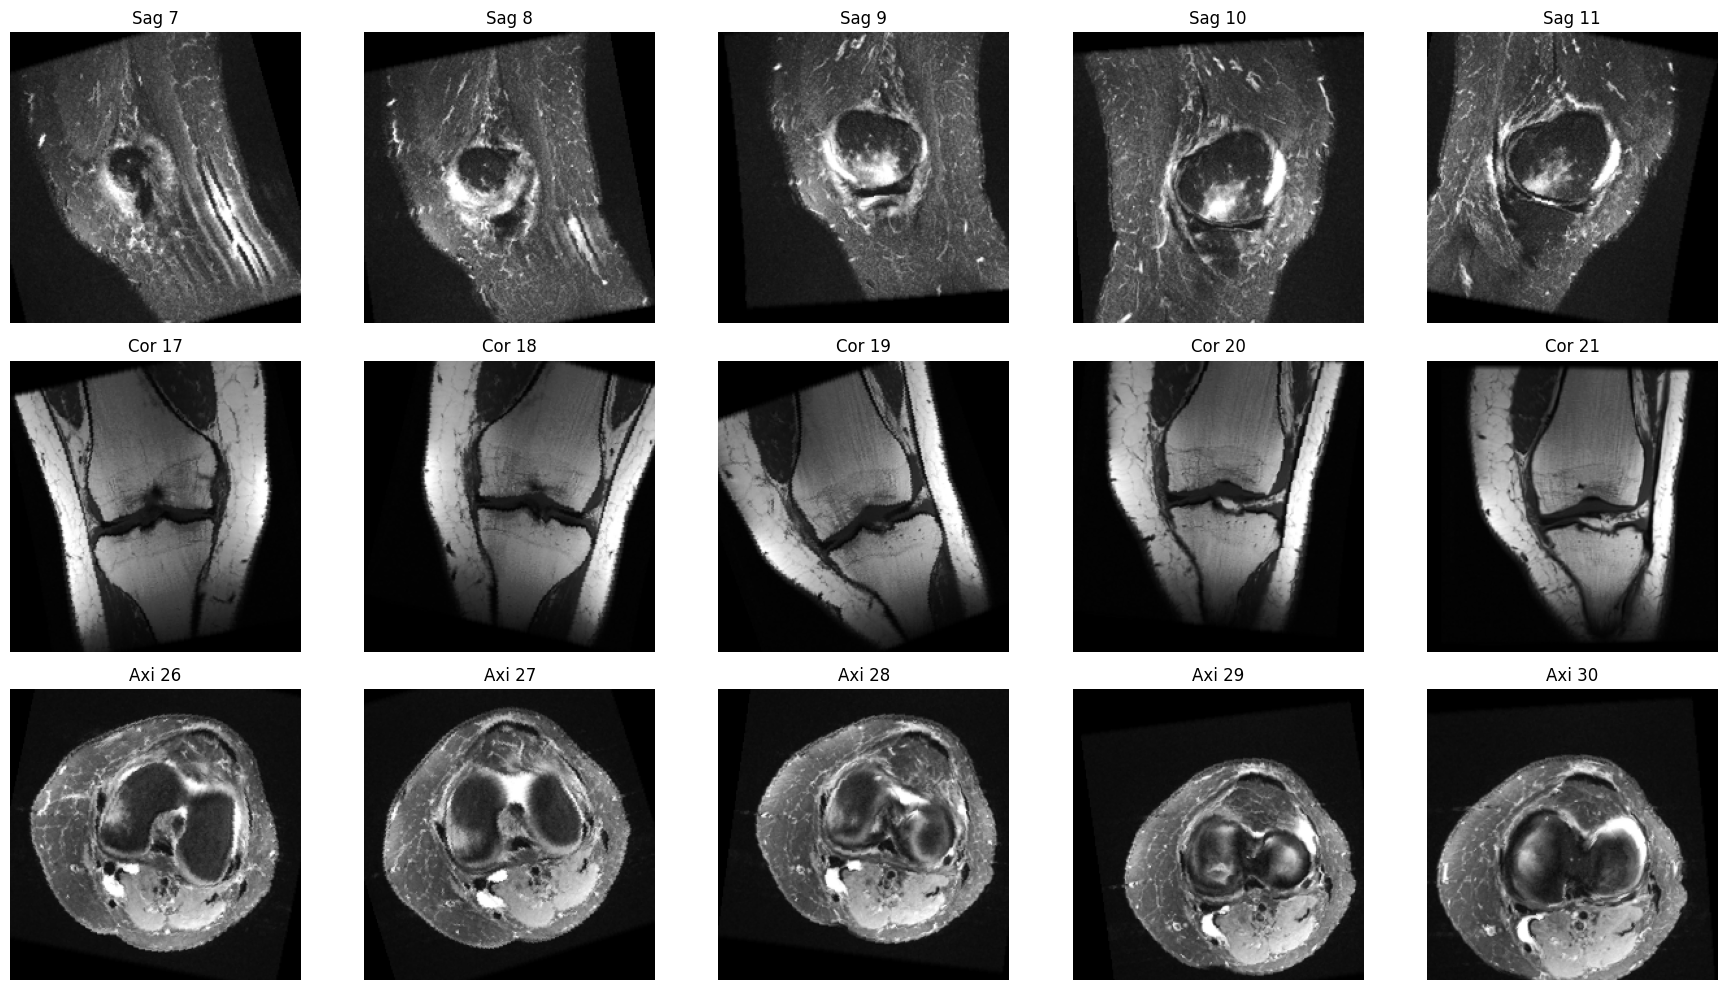

In [18]:
def denorm(x):
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3,1,1)
    std = torch.tensor([0.25, 0.25, 0.25]).view(3,1,1)
    return x * std + mean

sample = train_ds[0]

fig, axes = plt.subplots(3, CFG.NUM_SLICES_PER_VIEW, figsize=(18, 10))

for i in range(CFG.NUM_SLICES_PER_VIEW):
    axes[0, i].imshow(np.clip(denorm(sample["sag"][i]).permute(1,2,0).numpy(), 0, 1))
    axes[0, i].set_title(f"Sag {sample['sag_idxs'][i]}")
    axes[0, i].axis("off")

    axes[1, i].imshow(np.clip(denorm(sample["cor"][i]).permute(1,2,0).numpy(), 0, 1))
    axes[1, i].set_title(f"Cor {sample['cor_idxs'][i]}")
    axes[1, i].axis("off")

    axes[2, i].imshow(np.clip(denorm(sample["axi"][i]).permute(1,2,0).numpy(), 0, 1))
    axes[2, i].set_title(f"Axi {sample['axi_idxs'][i]}")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

## 🔥 18. Focal Loss

`MultiLabelFocalLoss` combines Binary Cross-Entropy with a focal term `(1 - p_t)^γ` to down-weight easy negatives. Positive class weights are applied per label.

In [19]:
class MultiLabelFocalLoss(nn.Module):
    def __init__(self, pos_weight=None, alpha=1.0, gamma=2.0, reduction="mean"):
        super().__init__()
        self.pos_weight = pos_weight
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            pos_weight=self.pos_weight,
            reduction="none"
        )

        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)
        focal_term = (1 - pt) ** self.gamma

        loss = self.alpha * focal_term * bce

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

## 🤖 19. Model — MultiLabelMultiViewViT

The model encodes each view independently using a shared ViT backbone, then fuses view-level features using a **learned gating network** before passing the concatenated representation through the classification head.

```
ViT-Small → mean-pool slices → [B, F]
                               × 3 views
                               → View Gate (Softmax)
                               → Weighted concat [B, 3F]
                               → LayerNorm → Linear(512) → GELU → Dropout → Linear(3)
```

In [20]:
class MultiLabelMultiViewViT(nn.Module):
    def __init__(self, model_name="vit_small_patch16_224", num_labels=3, pretrained=True):
        super().__init__()

        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0
        )

        feat_dim = self.backbone.num_features

        self.view_gate = nn.Sequential(
            nn.Linear(feat_dim * 3, 3),
            nn.Softmax(dim=1)
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim * 3),
            nn.Linear(feat_dim * 3, 512),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_labels)
        )

    def encode_view(self, x):
        """
        x: [B, S, C, H, W]
        """
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)
        feats = self.backbone(x)             # [B*S, F]
        feats = feats.view(B, S, -1)         # [B, S, F]
        feats = feats.mean(dim=1)            # [B, F]
        return feats

    def forward(self, sag, cor, axi):
        fs = self.encode_view(sag)
        fc = self.encode_view(cor)
        fa = self.encode_view(axi)

        concat = torch.cat([fs, fc, fa], dim=1)   # [B, 3F]
        gates = self.view_gate(concat)            # [B, 3]

        g1 = gates[:, 0:1]
        g2 = gates[:, 1:2]
        g3 = gates[:, 2:3]

        fs = fs * g1
        fc = fc * g2
        fa = fa * g3

        fused = torch.cat([fs, fc, fa], dim=1)
        logits = self.classifier(fused)
        return logits

## 🏗️ 20. Instantiate Model

Create the model and move it to the available device (CUDA or CPU).

In [21]:
model = MultiLabelMultiViewViT(
    model_name=CFG.MODEL_NAME,
    num_labels=CFG.NUM_LABELS,
    pretrained=True
).to(CFG.DEVICE)

print(model)

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

MultiLabelMultiViewViT(
  (backbone): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=384, out_features=1536, bias=True)

## 🛠️ 21. Loss, Optimiser, Scheduler

- **Loss:** Focal Loss with positive class weights
- **Optimiser:** AdamW with differential learning rates (`5e-6` backbone, `5e-5` head)
- **Scheduler:** CosineAnnealingLR

In [22]:
criterion = MultiLabelFocalLoss(
    pos_weight=pos_weights.to(CFG.DEVICE),
    alpha=1.0,
    gamma=2.0,
    reduction="mean"
)

backbone_params = list(model.backbone.parameters())
head_params = list(model.view_gate.parameters()) + list(model.classifier.parameters())

optimizer = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": CFG.BACKBONE_LR},
        {"params": head_params, "lr": CFG.HEAD_LR},
    ],
    weight_decay=CFG.WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG.EPOCHS
)

## 📐 22. Metric Helpers

Utilities to compute macro F1 and per-label AUC-ROC.

In [23]:
def multilabel_macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

def compute_per_label_auc(y_true, y_prob, label_names):
    aucs = {}
    for i, label in enumerate(label_names):
        try:
            aucs[label] = roc_auc_score(y_true[:, i], y_prob[:, i])
        except:
            aucs[label] = np.nan
    return aucs

## 🏃 23. Training Loop

`train_one_epoch` runs one full pass over the training set, accumulating loss and F1.

In [24]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    all_targets = []
    all_probs = []

    for batch in loader:
        sag = batch["sag"].to(device)
        cor = batch["cor"].to(device)
        axi = batch["axi"].to(device)
        targets = batch["target"].to(device)

        optimizer.zero_grad()

        logits = model(sag, cor, axi)
        loss = criterion(logits, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * targets.size(0)

        probs = torch.sigmoid(logits)
        all_targets.append(targets.detach().cpu())
        all_probs.append(probs.detach().cpu())

    epoch_loss = running_loss / len(loader.dataset)

    all_targets = torch.cat(all_targets).numpy()
    all_probs = torch.cat(all_probs).numpy()
    all_preds = (all_probs >= 0.5).astype(int)

    epoch_f1 = multilabel_macro_f1(all_targets, all_preds)

    return epoch_loss, epoch_f1

## 🧪 24. Validation Loop

`valid_one_epoch` evaluates the model without gradient computation, returning loss, F1, per-label AUCs, and raw predictions.

In [25]:
@torch.no_grad()
def valid_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_targets = []
    all_probs = []
    all_ids = []

    for batch in loader:
        sag = batch["sag"].to(device)
        cor = batch["cor"].to(device)
        axi = batch["axi"].to(device)
        targets = batch["target"].to(device)

        logits = model(sag, cor, axi)
        loss = criterion(logits, targets)

        running_loss += loss.item() * targets.size(0)

        probs = torch.sigmoid(logits)

        all_targets.append(targets.detach().cpu())
        all_probs.append(probs.detach().cpu())
        all_ids.extend(batch["id"])

    epoch_loss = running_loss / len(loader.dataset)

    all_targets = torch.cat(all_targets).numpy()
    all_probs = torch.cat(all_probs).numpy()
    all_preds = (all_probs >= 0.5).astype(int)

    epoch_f1 = multilabel_macro_f1(all_targets, all_preds)
    aucs = compute_per_label_auc(all_targets, all_probs, CFG.LABEL_NAMES)

    return epoch_loss, epoch_f1, all_targets, all_probs, all_preds, all_ids, aucs

## 🚀 25. Training

Train for `CFG.EPOCHS` epochs, saving the best checkpoint by validation macro F1.

In [26]:
best_f1 = -1
best_model_path = "/kaggle/working/best_multilabel_multiview_vit.pth"

history = {
    "train_loss": [],
    "train_f1": [],
    "valid_loss": [],
    "valid_f1": []
}

for epoch in range(CFG.EPOCHS):
    train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, CFG.DEVICE)
    valid_loss, valid_f1, _, _, _, _, aucs = valid_one_epoch(model, valid_loader, criterion, CFG.DEVICE)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_f1"].append(train_f1)
    history["valid_loss"].append(valid_loss)
    history["valid_f1"].append(valid_f1)

    print(
        f"Epoch {epoch+1}/{CFG.EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | "
        f"Valid Loss: {valid_loss:.4f} | Valid F1: {valid_f1:.4f} | "
        f"AUCs: {aucs}"
    )

    if valid_f1 > best_f1:
        best_f1 = valid_f1
        torch.save(model.state_dict(), best_model_path)

print("Best model saved to:", best_model_path)

Epoch 1/15 | Train Loss: 0.1936 | Train F1: 0.7711 | Valid Loss: 0.1930 | Valid F1: 0.7566 | AUCs: {'acl': np.float64(0.7735690235690236), 'meniscus': np.float64(0.7324660633484164), 'abnormal': np.float64(0.8042105263157895)}
Epoch 2/15 | Train Loss: 0.1824 | Train F1: 0.7776 | Valid Loss: 0.2014 | Valid F1: 0.7334 | AUCs: {'acl': np.float64(0.8305274971941639), 'meniscus': np.float64(0.7270927601809954), 'abnormal': np.float64(0.872)}
Epoch 3/15 | Train Loss: 0.1637 | Train F1: 0.8042 | Valid Loss: 0.1780 | Valid F1: 0.7453 | AUCs: {'acl': np.float64(0.8585858585858586), 'meniscus': np.float64(0.7245475113122172), 'abnormal': np.float64(0.8673684210526317)}
Epoch 4/15 | Train Loss: 0.1535 | Train F1: 0.8176 | Valid Loss: 0.1873 | Valid F1: 0.7545 | AUCs: {'acl': np.float64(0.8296857463524131), 'meniscus': np.float64(0.7222850678733032), 'abnormal': np.float64(0.8972631578947369)}
Epoch 5/15 | Train Loss: 0.1399 | Train F1: 0.8441 | Valid Loss: 0.1761 | Valid F1: 0.7705 | AUCs: {'acl'

## 📈 26. Training Curves

Plot training and validation loss and macro F1 over epochs to inspect convergence and overfitting.

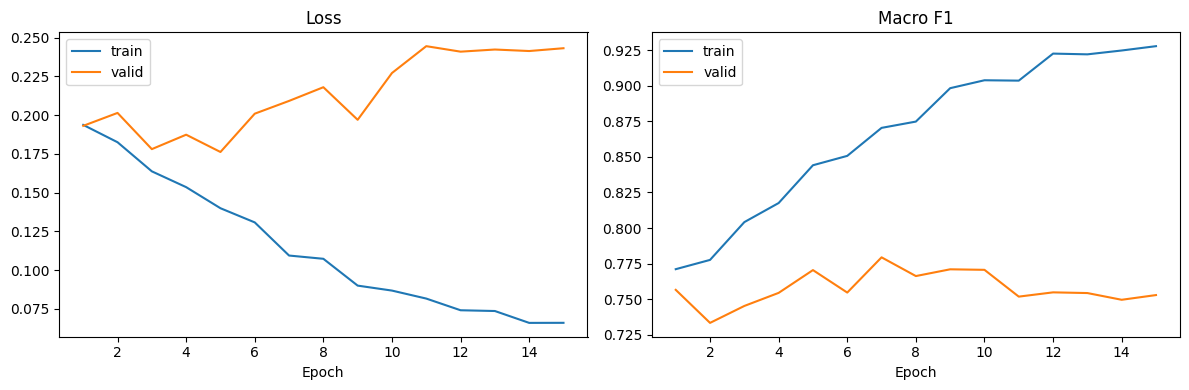

In [27]:
epochs = range(1, CFG.EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["valid_loss"], label="valid")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_f1"], label="train")
plt.plot(epochs, history["valid_f1"], label="valid")
plt.title("Macro F1")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

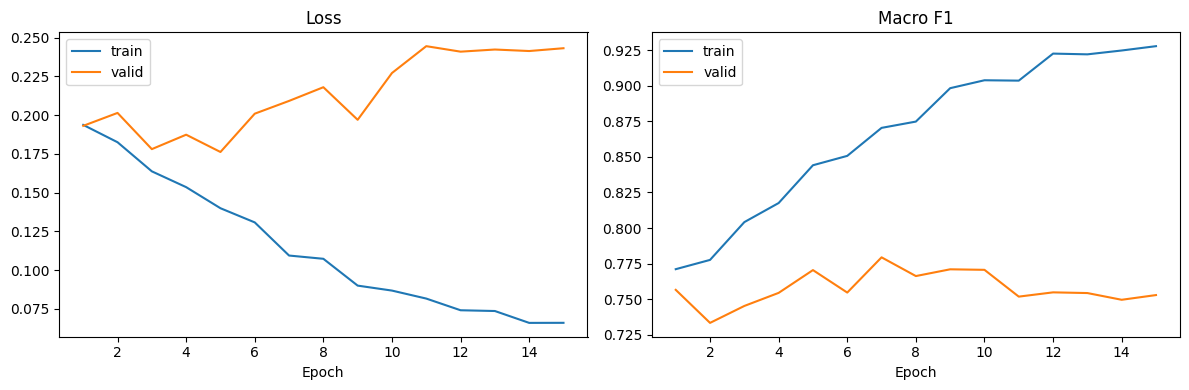

In [28]:
epochs = range(1, CFG.EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["valid_loss"], label="valid")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_f1"], label="train")
plt.plot(epochs, history["valid_f1"], label="valid")
plt.title("Macro F1")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

## 📋 27. Final Evaluation

Load the best checkpoint and run a full evaluation pass on the validation set.

In [29]:
model.load_state_dict(torch.load(best_model_path, map_location=CFG.DEVICE))

valid_loss, valid_f1, y_true, y_prob, y_pred, exam_ids, aucs = valid_one_epoch(
    model, valid_loader, criterion, CFG.DEVICE
)

print("Final Validation Loss:", round(valid_loss, 4))
print("Final Validation Macro F1:", round(valid_f1, 4))
print("Per-label AUCs:", aucs)

Final Validation Loss: 0.2091
Final Validation Macro F1: 0.7794
Per-label AUCs: {'acl': np.float64(0.88327721661055), 'meniscus': np.float64(0.7061651583710408), 'abnormal': np.float64(0.9322105263157895)}


## 📄 28. Per-Label Classification Reports

Print precision, recall, F1, and support for each label individually.

In [30]:
for i, label in enumerate(CFG.LABEL_NAMES):
    print("=" * 60)
    print(f"Label: {label}")
    print(classification_report(y_true[:, i], y_pred[:, i], digits=4, zero_division=0))

Label: acl
              precision    recall  f1-score   support

         0.0     0.7808    0.8636    0.8201        66
         1.0     0.8085    0.7037    0.7525        54

    accuracy                         0.7917       120
   macro avg     0.7947    0.7837    0.7863       120
weighted avg     0.7933    0.7917    0.7897       120

Label: meniscus
              precision    recall  f1-score   support

         0.0     0.8000    0.4706    0.5926        68
         1.0     0.5500    0.8462    0.6667        52

    accuracy                         0.6333       120
   macro avg     0.6750    0.6584    0.6296       120
weighted avg     0.6917    0.6333    0.6247       120

Label: abnormal
              precision    recall  f1-score   support

         0.0     0.7647    0.5200    0.6190        25
         1.0     0.8835    0.9579    0.9192        95

    accuracy                         0.8667       120
   macro avg     0.8241    0.7389    0.7691       120
weighted avg     0.8587    0.86

## 💾 29. Predictions DataFrame

Collect all exam IDs, true labels, predicted labels, and raw probabilities into a structured DataFrame.

In [31]:
rows = []
for i in range(len(exam_ids)):
    rows.append({
        "id": exam_ids[i],
        "true_acl": int(y_true[i, 0]),
        "true_meniscus": int(y_true[i, 1]),
        "true_abnormal": int(y_true[i, 2]),
        "pred_acl": int(y_pred[i, 0]),
        "pred_meniscus": int(y_pred[i, 1]),
        "pred_abnormal": int(y_pred[i, 2]),
        "prob_acl": float(y_prob[i, 0]),
        "prob_meniscus": float(y_prob[i, 1]),
        "prob_abnormal": float(y_prob[i, 2]),
    })

pred_df = pd.DataFrame(rows)
pred_df.head()

,id,true_acl,true_meniscus,true_abnormal,pred_acl,pred_meniscus,pred_abnormal,prob_acl,prob_meniscus,prob_abnormal
0,1130,0,0,0,0,0,0,0.256028,0.274832,0.399878
1,1131,0,0,0,0,0,0,0.284605,0.370327,0.455326
2,1132,0,0,0,0,0,0,0.377798,0.378044,0.436380
3,1133,0,0,0,0,0,0,0.190538,0.255381,0.292385
4,1134,0,0,0,0,0,1,0.236427,0.472255,0.576382


## 📤 30. Save Outputs

Export the predictions CSV and final model weights.

In [32]:
pred_df.to_csv("/kaggle/working/multilabel_multiview_predictions.csv", index=False)
torch.save(model.state_dict(), "/kaggle/working/final_multilabel_multiview_vit.pth")

print("Saved:")
print("/kaggle/working/multilabel_multiview_predictions.csv")
print("/kaggle/working/final_multilabel_multiview_vit.pth")

Saved:
/kaggle/working/multilabel_multiview_predictions.csv
/kaggle/working/final_multilabel_multiview_vit.pth


## 🔬 31. Single Sample Inference

Run inference on one validation example and display the predicted vs true labels.

In [33]:
sample = valid_ds[0]

model.eval()
with torch.no_grad():
    sag = sample["sag"].unsqueeze(0).to(CFG.DEVICE)
    cor = sample["cor"].unsqueeze(0).to(CFG.DEVICE)
    axi = sample["axi"].unsqueeze(0).to(CFG.DEVICE)

    logits = model(sag, cor, axi)
    probs = torch.sigmoid(logits)[0].cpu().numpy()
    preds = (probs >= 0.5).astype(int)

print("Exam ID:", sample["id"])
print("True:", sample["target"].numpy())
print("Pred:", preds)
print("Probabilities:", probs)

Exam ID: 1130
True: [0. 0. 0.]
Pred: [0 0 0]
Probabilities: [0.25602782 0.2748322  0.39987838]


## 🧹 32. Cleanup

Free GPU memory and run the garbage collector.

In [34]:
gc.collect()
torch.cuda.empty_cache()
print("Cleanup done.")

Cleanup done.
